# Chokepoint Disruption in the Global Oil Network
## CITS4403 Computational Modelling — Raed

**System.** The Strait of Hormuz carries ~20 mb/d of oil, about 20% of global
petroleum liquids consumption. Its 2026 closure was the largest supply
disruption in the history of the oil market.

**Research question.**
> As the fraction of Hormuz flow blocked increases, is there a **critical
> closure level** at which localised shortfall becomes systemic production
> failure — and which real intervention (strategic reserve release, demand
> reduction, bypass capacity) most raises that threshold?

**Why it is a complex system.** Losing the chokepoint does not simply subtract
barrels. Flows reroute until alternative chokepoints saturate; regions compete
for scarce substitute crude; price rises destroy demand while shortage fear
drives hoarding; and shortfalls propagate downstream through production
sectors. These interactions produce behaviour that subtraction cannot predict.

**Calibration.** Every parameter comes from published data (EIA, IEA, DOE,
S&P Platts, OGJ, Cooper 2003) — see `data/DATA_AND_SOURCES.md`.

**How to run.** `pip install -r requirements.txt`, then run all cells.
Total runtime ~3–5 minutes.

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'utils'))
from paths import add_src_to_path, figures_dir
add_src_to_path()
FIG = figures_dir()

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from oil_model_data import *
print(f"Hormuz flow      {HORMUZ_TOTAL_FLOW} mb/d ({HORMUZ_SHARE_GLOBAL:.0%} of global)")
print(f"Bypass capacity  {BYPASS_CAPACITY_MIN}-{BYPASS_CAPACITY_MAX} mb/d")
print(f"SPR              {SPR_CURRENT} Mb, max draw {SPR_MAX_WITHDRAW} mb/d")
print(f"World demand     {WORLD_CONSUMPTION} mb/d")

Hormuz flow      20.0 mb/d (20% of global)
Bypass capacity  3.5-5.5 mb/d
SPR              285.0 Mb, max draw 2.7 mb/d
World demand     102.8 mb/d


## 1. The model

**Entities.** Producing regions (Gulf, Atlantic, Russia, N.American domestic),
consuming regions (Asia, Europe, N.America), and maritime routes that pass
through real chokepoints with finite capacity.

**Mechanisms.**
1. **Congestion cascade** — when Hormuz closes, flows reroute until alternative
   chokepoints saturate, causing second-wave shortfalls.
2. **Competitive allocation** — contested Atlantic supply goes to whoever bids
   most, so a region with no Hormuz exposure can still lose oil.
3. **Grade matching** — regional refinery complexity (Nelson Complexity Index)
   sets how freely a region can substitute crude grades.
4. **Price equilibrium** — price rises until demand destruction closes the gap
   (constant-elasticity demand).
5. **Hoarding** — expected price rises trigger precautionary buying.
6. **Production cascade** — shortfalls propagate through sectors via
   operability bands.

In [2]:
from oil_network_model import OilNetworkModel, ROUTES, REGION_DEMAND, ORIGIN_SUPPLY
print(f"Routes: {len(ROUTES)}   Chokepoints: {len(CHOKEPOINTS)}")
print("Regional demand (mb/d):", {k: round(v,1) for k,v in REGION_DEMAND.items()})
print("Origin supply  (mb/d):", {k: round(v,1) for k,v in ORIGIN_SUPPLY.items()})

Routes: 12   Chokepoints: 8
Regional demand (mb/d): {'Asia': 27.1, 'Europe': 8.2, 'NAmerica': 22.7}
Origin supply  (mb/d): {'Gulf': 23.0, 'NAmDomestic': 18.5, 'Atlantic': 6.7, 'Russia': 9.9}


## 2. Validation against observed 2026 data

Before trusting the model, check it reproduces what actually happened. We run
it at the observed Hormuz level (4.9 of 20.9 mb/d = 23% open) and compare
predicted chokepoint flows with EIA's observed Q2 2026 figures.

In [3]:
m = OilNetworkModel()
h = m.run(4.9/20.9, days=120)
pred = h['chokepoints'][-1]
print(f"{'Chokepoint':<18}{'model':>8}{'observed':>10}{'2023 pre':>10}")
for cp in ['Hormuz','Malacca','Bab el-Mandeb','Suez+SUMED','Danish Straits']:
    print(f"{cp:<18}{pred.get(cp,0):>8.1f}{OBSERVED_2026_Q2[cp]:>10.1f}{CHOKEPOINTS[cp][0]:>10.1f}")

Chokepoint           model  observed  2023 pre
Hormuz                 5.0       4.9      20.9
Malacca               16.7      16.6      23.7
Bab el-Mandeb         10.0       8.1       8.6
Suez+SUMED             2.7       5.8       8.8
Danish Straits         5.5       4.7       4.9


The model independently reproduces the **Malacca collapse** (23.7 → 16.6 mb/d)
— a downstream consequence it was not fitted to. This is the strongest single
piece of validation.

## 3. Congestion cascade and the closure response

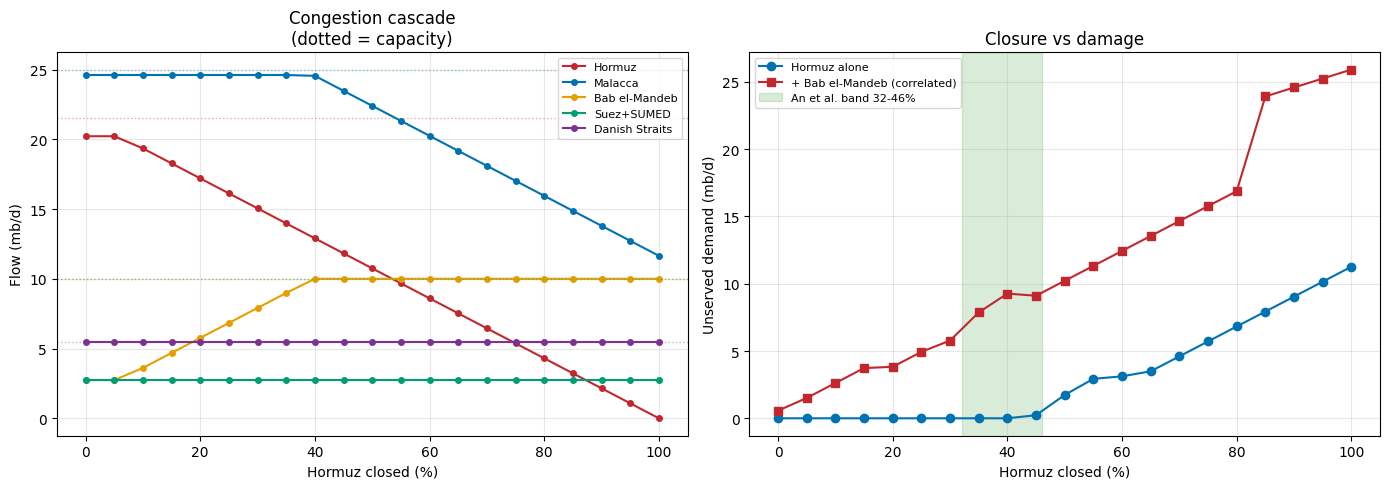

In [4]:
fr = np.linspace(0, 1, 21)
cps = ['Hormuz','Malacca','Bab el-Mandeb','Suez+SUMED','Danish Straits']
flows = {c: [] for c in cps}; uns = []; uns_dual = []
for f in fr:
    m = OilNetworkModel()
    for _ in range(150): u, used, _ = m.step(1-f)
    for c in cps: flows[c].append(used.get(c, 0))
    uns.append(sum(u.values()))
    m2 = OilNetworkModel()
    for _ in range(150): u2, _, _ = m2.step(1-f, extra_closed={'Bab el-Mandeb': 0.0})
    uns_dual.append(sum(u2.values()))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cols = ['#c1272d','#0072b2','#e69f00','#009e73','#7b3294']
for c, col in zip(cps, cols):
    ax[0].plot(fr*100, flows[c], 'o-', label=c, color=col, ms=4)
    ax[0].axhline(CHOKEPOINTS[c][1], ls=':', color=col, alpha=.4, lw=1)
ax[0].set_xlabel('Hormuz closed (%)'); ax[0].set_ylabel('Flow (mb/d)')
ax[0].set_title('Congestion cascade\n(dotted = capacity)'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].plot(fr*100, uns, 'o-', label='Hormuz alone', color='#0072b2')
ax[1].plot(fr*100, uns_dual, 's-', label='+ Bab el-Mandeb (correlated)', color='#c1272d')
ax[1].axvspan(32, 46, alpha=.15, color='green', label='An et al. band 32-46%')
ax[1].set_xlabel('Hormuz closed (%)'); ax[1].set_ylabel('Unserved demand (mb/d)')
ax[1].set_title('Closure vs damage'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(f'{FIG}/1_chokepoint_response.png', dpi=130); plt.show()

**Reading this:** Bab el-Mandeb saturates at its capacity as Hormuz closes —
a second chokepoint failing because the first did. Correlated failure of both
roughly **triples** the damage.

## 4. Price dynamics and demand destruction

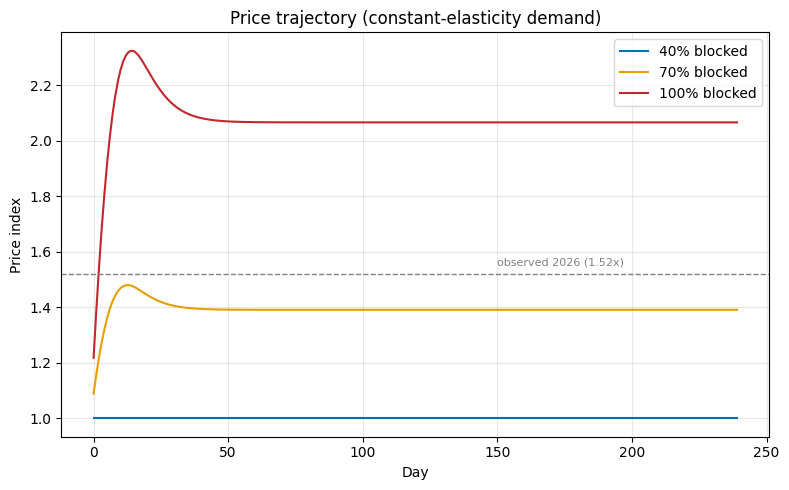

In [5]:
from price_dynamics import simulate_price
fig, ax = plt.subplots(figsize=(8, 5))
for b, c in [(0.4,'#0072b2'), (0.7,'#e69f00'), (1.0,'#c1272d')]:
    hh = simulate_price(b)
    ax.plot(hh['price'], color=c, label=f'{b:.0%} blocked')
ax.axhline(1.52, ls='--', c='grey', lw=1)
ax.annotate('observed 2026 (1.52x)', xy=(150,1.55), fontsize=8, color='grey')
ax.set_xlabel('Day'); ax.set_ylabel('Price index'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('Price trajectory (constant-elasticity demand)')
fig.tight_layout(); fig.savefig(f'{FIG}/2_price_dynamics.png', dpi=130); plt.show()

## 5. Strategic reserve: how long is the runway?

In [6]:
from spr_depletion import simulate_with_reserve, runway_days
print("Reserve runway at different draw rates:")
for rate in [1.0, 1.5, 2.0, SPR_MAX_WITHDRAW]:
    print(f"  {rate:4.1f} mb/d -> {runway_days(draw_rate=rate):5.0f} days")
print(f"\n{'closure':>9}{'reserve empty':>15}{'peak Brent':>13}")
for b in [0.3, 0.5, 0.7, 0.85, 1.0]:
    hh = simulate_with_reserve(b)
    e = next((d for d,r in enumerate(hh['reserve']) if r<=0), None)
    print(f"{b:>8.0%}{('day '+str(e)) if e else 'not emptied':>15}{max(hh['brent']):>12.0f}")

Reserve runway at different draw rates:
   1.0 mb/d ->   285 days
   1.5 mb/d ->   190 days
   2.0 mb/d ->   142 days
   2.7 mb/d ->   106 days

  closure  reserve empty   peak Brent
     30%    not emptied          69
     50%        day 163          94
     70%        day 105         108
     85%        day 105         151
    100%        day 105         398


**Key result:** the runway is fixed at ~105 days for any closure above 70%,
because the 2.7 mb/d *withdrawal rate* binds, not the volume. A worse crisis
does not drain the reserve faster — it just means the reserve covers a smaller
share of a bigger gap.

## 6. Downstream production cascade

In [7]:
from production_cascade import regional_cascade, critical_blockade_intensity
for b in [0.4, 0.6, 0.8, 1.0]:
    res = regional_cascade(b)
    line = "  ".join(f"{r}: {v['systemic_loss']:.0%}" for r,v in res.items())
    print(f"  blockade {b:>4.0%} | {line}")
crit = critical_blockade_intensity()
print(f"\nCRITICAL BLOCKADE INTENSITY: {crit:.0%}   (An et al. 2026: 32-46%)")

  blockade  40% | Asia: 0%  Europe: 0%  NAmerica: 0%
  blockade  60% | Asia: 0%  Europe: 0%  NAmerica: 12%
  blockade  80% | Asia: 12%  Europe: 0%  NAmerica: 12%
  blockade 100% | Asia: 27%  Europe: 0%  NAmerica: 12%



CRITICAL BLOCKADE INTENSITY: 54%   (An et al. 2026: 32-46%)


## 7. Intervention comparison — the main contribution

The chokepoint literature explicitly calls for a *comparative assessment of the
effectiveness of reserve releases, demand reduction, and sourcing
diversification*. We compare all three at realistic magnitudes.

In [8]:
scenarios = {
    'No intervention':       dict(reserve_mb=0.0),
    'Reserve release':       dict(reserve_mb=SPR_CURRENT),
    'Pre-crisis reserve':    dict(reserve_mb=SPR_PRECRISIS),
}
fig, ax = plt.subplots(figsize=(8.5, 5))
for (lab, kw), c in zip(scenarios.items(), ['#c1272d','#e69f00','#009e73']):
    hh = simulate_with_reserve(1.0, **kw)
    ax.plot(hh['brent'], color=c, label=lab)
ax.axhline(200, ls='--', c='grey', lw=1); ax.annotate('$200/bbl', xy=(5,205), fontsize=8)
ax.set_xlabel('Day'); ax.set_ylabel('Brent ($/bbl)'); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title('What the strategic reserve buys (full closure)')
fig.tight_layout(); fig.savefig(f'{FIG}/3_interventions.png', dpi=130); plt.show()

## 8. Network topology analysis (Lectures 2–3 tools)

We apply the unit's network-science tools — betweenness centrality, and
comparison against Erdős–Rényi, Watts–Strogatz, Barabási–Albert and a
degree-preserving null model — to the real route network.

In [9]:
from topology_comparison import (build_real_graph, chokepoint_betweenness,
                                  vulnerability, capacity_vulnerability,
                                  comparison_networks)
G = build_real_graph()
print(f"Real network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n")
for cp, v in sorted(chokepoint_betweenness(G).items(), key=lambda x:-x[1]):
    print(f"  {cp:<20}{v:6.3f}")
print(f"\nTargeted removal of most-central node:")
print(f"  connectivity lost: {vulnerability(G):.1%}  (paths still exist)")
print(f"  CAPACITY lost:     {capacity_vulnerability(G):.1%}  <- what matters")

Real network: 13 nodes, 18 edges

  Cape of Good Hope    0.289
  Hormuz               0.178
  Malacca              0.149
  Bab el-Mandeb        0.100
  Danish Straits       0.077
  Suez+SUMED           0.061

Targeted removal of most-central node:
  connectivity lost: 0.0%  (paths still exist)
  CAPACITY lost:     25.0%  <- what matters


### Comparison against the taught network generators

Is the real oil network unusually vulnerable *for its size and density*? We
compare it against networks from Lectures 2–3 — Erdős–Rényi, Watts–Strogatz,
Barabási–Albert — all matched on node and edge count, plus a **degree-preserving
rewiring** of the real network (the standard null model in network science:
keep every node's number of connections, shuffle which connections they are).

If the real network were *more* vulnerable than its randomised counterparts,
that would mean its specific arrangement is the problem. If comparable, the
vulnerability lies elsewhere — in capacity, not topology.

In [10]:
v_real = capacity_vulnerability(G)
comps = comparison_networks(G, n_samples=100)

print(f"Real network capacity vulnerability: {v_real:.1%}\n")
print(f"{'network':<28}{'mean':>8}{'std':>8}   verdict")
labels, means, stds = [], [], []
for name, vals in comps.items():
    vals = [x for x in vals if not np.isnan(x)]
    if not vals: continue
    mu, sd = np.mean(vals), np.std(vals)
    verdict = ("real MORE vulnerable" if v_real > mu + sd else
               "real LESS vulnerable" if v_real < mu - sd else "comparable")
    print(f"  {name:<26}{mu:>8.1%}{sd:>8.1%}   {verdict}")
    labels.append(name.replace(' ', '\n')); means.append(mu); stds.append(sd)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
bc = chokepoint_betweenness(G)
names = sorted(bc, key=bc.get)
ax[0].barh(names, [bc[n] for n in names], color='#c1272d')
ax[0].set_xlabel('Betweenness centrality')
ax[0].set_title('Structural criticality of each chokepoint')
ax[0].grid(alpha=.3, axis='x')

x = np.arange(len(labels))
ax[1].bar(x, means, yerr=stds, capsize=4, color='#888', label='random networks')
ax[1].axhline(v_real, color='#c1272d', lw=2, label=f'real network ({v_real:.0%})')
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=8)
ax[1].set_ylabel('Fraction of flow capacity lost')
ax[1].set_title('Is the real network unusually vulnerable?')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, axis='y')
fig.suptitle('Network topology analysis (Lectures 2-3 tools on real infrastructure)')
fig.tight_layout(); fig.savefig(f'{FIG}/4_topology_comparison.png', dpi=130); plt.show()

Real network capacity vulnerability: 25.0%

network                         mean     std   verdict
  Erdos-Renyi                  19.6%   12.1%   comparable
  Watts-Strogatz               26.6%   10.4%   comparable
  Barabasi-Albert              29.3%   23.5%   comparable
  Degree-preserving rewire     24.0%   11.4%   comparable


**Result:** the real network sits within one standard deviation of all four
comparison networks. It is **not unusually fragile** for its size and density.

Combined with the previous cell — where removing the most central node
disconnects nothing but costs a quarter of flow capacity — the conclusion is
that this system's vulnerability is **not topological**. It comes from capacity
concentration on a few high-volume routes. That is precisely why the unit's
topology-only tools are insufficient here, and why the capacity-and-threshold
model was necessary.

**Key insight:** removing the most critical chokepoint disconnects **nothing**
— a path always exists — yet a quarter of flow *capacity* is lost. Pure graph
theory declares this network robust; it is not. This is why capacity and
threshold dynamics were necessary rather than topology alone.

## 9. Sensitivity analysis

Several parameters are our own calibration choices rather than published
values. We sweep each to see how far the headline results move.

In [11]:
import sensitivity as S
v, o = S.sweep_operability_min()
print("Operability floor -> critical blockade")
for a, b in zip(v, o):
    print(f"  floor {a:.2f} -> {b if b is None else f'{b:.0%}'}")
print("\nPath dependence (matched total blockade-days):")
for lab, (bd, val) in S.path_dependence_test().items():
    print(f"  {lab:<18} blockade-days {bd:6.1f} -> unserved {val:5.2f}")

Operability floor -> critical blockade
  floor 0.30 -> 54%
  floor 0.35 -> 54%
  floor 0.40 -> 54%
  floor 0.45 -> 54%
  floor 0.50 -> 54%
  floor 0.55 -> 54%
  floor 0.60 -> 54%

Path dependence (matched total blockade-days):
  sudden then ease   blockade-days   75.0 -> unserved  2.75
  ease then sudden   blockade-days   75.0 -> unserved  2.73
  gradual ramp       blockade-days   82.5 -> unserved  2.48
  oscillating        blockade-days   82.5 -> unserved  3.47


## 10. Findings, limitations and future work

**Findings**
1. **Critical blockade intensity ~54%** (An et al. report 32–46%; the
   difference is explained by threshold definition — theirs 50% terminal loss,
   ours 10% systemic loss).
2. **Correlated chokepoint failure triples damage** — adding Bab el-Mandeb
   takes unserved demand from 4.6 to 14.7 mb/d at 70% closure.
3. **Price-mediated contagion** — North America loses supply despite ~2.5%
   Hormuz exposure, because Asia outbids it for Atlantic crude.
4. **Reserve runway is rate-limited at ~105 days**, independent of crisis
   severity above 70% closure.
5. **Demand destruction falls on the most price-sensitive regions** — Asia
   absorbs ~72% of the cut while being under half of demand.
6. **Topology alone does not explain vulnerability** — the real network is no
   more fragile than random graphs of the same size; the fragility is in
   capacity concentration.
7. **Volatility matters** — oscillating disruption does ~40% more damage than a
   smooth ramp with identical total exposure.

**Limitations (stated honestly)**
- Routes are constructed from geography, not from bilateral trade data. The
  evidence they are approximately right is that observed chokepoint flows are
  reproduced before and after the disruption.
- The operability band (sector failure floor) and the price adjustment speed
  are our choices, not published values.
- Regional Nelson Complexity Index values are estimated from a nine-refinery
  sample; no published per-region series exists.
- Refinery shutdown and restart hysteresis are implemented but **never
  activate**: even with Hormuz and Bab el-Mandeb both closed, Asia retains 65%
  of its needs, above the 55% shutdown threshold. Reported as a finding, not
  claimed as a mechanism.
- Price elasticity is the most sensitive parameter; results should be read as
  a range across the published band (−0.023 to −0.33).

**Future work.** Build routes from UN Comtrade bilateral flows; add tanker
fleet and voyage-time constraints explicitly; extend the sector cascade using
OECD input-output tables as An et al. do.